# 第 10 章 · 卷积代码实验

[章节网页](../ch10.html)

## 运行内容

- 计算 2D 卷积
- 展开窗口过程
- 绘制特征图

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备 6x6 输入图像和 3x3 边缘检测核。
image = np.array([
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 1],
], dtype=float)
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype=float)

feature = correlate2d(image, kernel, mode="valid")
display(pd.DataFrame(image.astype(int)))
display(pd.DataFrame(kernel.astype(int)))

,0,1,2,3,4,5
0,0,0,0,1,1,1
1,0,0,0,1,1,1
2,0,0,0,1,1,1
3,0,0,0,1,1,1
4,0,0,0,1,1,1
5,0,0,0,1,1,1


,0,1,2
0,-1,0,1
1,-1,0,1
2,-1,0,1


## 1. 卷积过程

In [3]:
# 展开每个窗口的卷积值。
rows = []
for i in range(feature.shape[0]):
    for j in range(feature.shape[1]):
        window = image[i:i + 3, j:j + 3]
        rows.append({
            "位置": f"({i},{j})",
            "窗口": window.astype(int).tolist(),
            "卷积值": int((window * kernel).sum()),
        })

conv_df = pd.DataFrame(rows)
display(conv_df.head(8))
display(pd.DataFrame(feature.astype(int)))

,位置,窗口,卷积值
0,"(0,0)","[[0, 0, 0], [0, 0, 0], [0, 0, 0]]",0
1,"(0,1)","[[0, 0, 1], [0, 0, 1], [0, 0, 1]]",3
2,"(0,2)","[[0, 1, 1], [0, 1, 1], [0, 1, 1]]",3
3,"(0,3)","[[1, 1, 1], [1, 1, 1], [1, 1, 1]]",0
4,"(1,0)","[[0, 0, 0], [0, 0, 0], [0, 0, 0]]",0
5,"(1,1)","[[0, 0, 1], [0, 0, 1], [0, 0, 1]]",3
6,"(1,2)","[[0, 1, 1], [0, 1, 1], [0, 1, 1]]",3
7,"(1,3)","[[1, 1, 1], [1, 1, 1], [1, 1, 1]]",0


,0,1,2,3
0,0,3,3,0
1,0,3,3,0
2,0,3,3,0
3,0,3,3,0


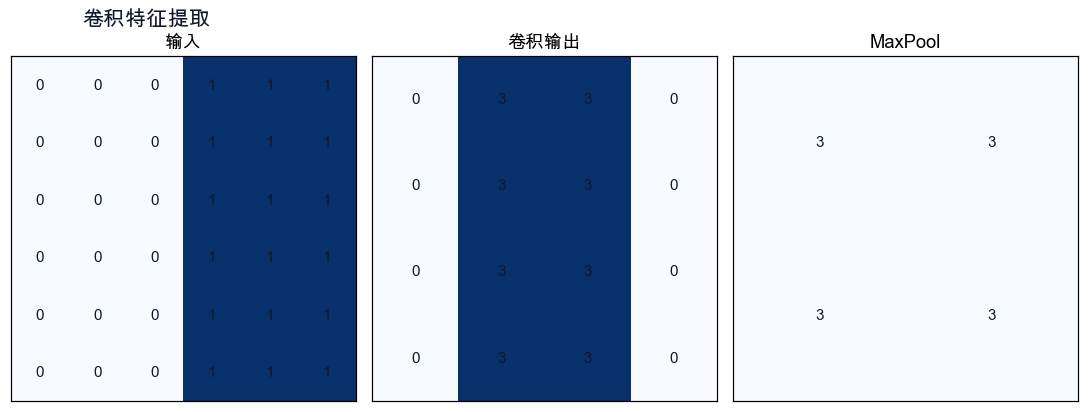

In [4]:
# 绘制输入、卷积输出和 2x2 max pooling。
pool = np.array([
    [feature[i:i + 2, j:j + 2].max() for j in range(0, feature.shape[1], 2)]
    for i in range(0, feature.shape[0], 2)
])

fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.8))
for ax, data, title in zip(axes, [image, feature, pool], ["输入", "卷积输出", "MaxPool"]):
    im = ax.imshow(data, cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.0f}", ha="center", va="center", color="#0f172a")
fig.suptitle("卷积特征提取", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()